# Word-Level Lyrics Generator Using LSTM

### Import Configurations

In [1]:
import math
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
from torch.nn.modules import transformer
from torch import accelerator
from torch import nn

device = accelerator.current_accelerator() if accelerator.is_available() else 'cpu'
print(f"Using {device} device")

Using cuda device


### Eminem Songs Dataset

In [2]:
song_data = pd.read_csv(r'data/mixed_lyrics.csv', index_col=0)
song_data.head()

,Title,Album,Year,Date,Lyric
Artist,,,,,
Nicki Minaj,Put You in a Room,The Pinkprint,2014.0,2014-12-15,put you in a room you ain't gotta leave you ai...
Drake,Fake Love,More Life,2016.0,2016-10-23,i've been down so long it look like up to me t...
Drake,Wu-Tang Forever,Nothing Was the Same,2013.0,2013-09-12,produced by noah 40 shebib i just love when ...
Coldplay,Everything’s Not Lost (Live @ Rockefeller Musi...,Trouble ‒ Norwegian Live EP,2001.0,2001-08-17,when i counted up my demons saw there was one ...
Coldplay,The Fall of Man,Unreleased Songs,NaN,NaN,sleep on the ocean sleep on the sand i've been...


In [3]:
print(song_data.shape)

(3094, 5)


### Data Inspection

In [4]:
print(song_data.info())
print(song_data.isna().sum())
print(f'Number of duplicated lyrics: {song_data['Lyric'].duplicated().sum()}')

<class 'pandas.core.frame.DataFrame'>
Index: 3094 entries, Nicki Minaj to Eminem
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Title   3094 non-null   object 
 1   Album   2248 non-null   object 
 2   Year    2212 non-null   float64
 3   Date    2212 non-null   object 
 4   Lyric   3094 non-null   object 
dtypes: float64(1), object(4)
memory usage: 145.0+ KB
None
Title      0
Album    846
Year     882
Date     882
Lyric      0
dtype: int64
Number of duplicated lyrics: 11


In [5]:
song_data['Lyric'] = song_data['Lyric'].drop_duplicates()

ValueError: cannot reindex on an axis with duplicate labels

In [6]:
lyrics_list = []
for lyric in song_data['Lyric']:
  if isinstance(lyric, str):
    lyrics_list.append(lyric)

print(len(lyrics_list))

3094


In [7]:
lyrics_list[:2]

["put you in a room you ain't gotta leave you ain't gotta leave but you can't sleep with me put you in a room you ain't gotta leave you ain't gotta leave but you can't sleep with me   every time i come and fuck with you you make up all the rules you ought to do it just because our car's moving are you in my fucking corner for real or are you plotting to kill i tell you just how i feel but you never hear oh why you take it like that now you wanna leave and never come back i don't control you i ain't never say that can't give up on you baby we go way back   put you in a room you ain't gotta leave you ain't gotta leave but you can't sleep with me put you in a room you ain't gotta leave you ain't gotta leave but you can't sleep with me   every time i try to fuck with you nothing ain't ever enough for you and i had all this hope for you but all you do is open wounds i could be fucking with them other niggas and no you ain't them other niggas i don't fuck with a lot of bitches just my real b

### Vocabulary Creation

In [8]:
all_words = []

for lyric in lyrics_list:
  all_words.extend(lyric.split())

min_freq = 5
word_counts = Counter(all_words)
vocab = [
    word
    for word, count in word_counts.items()
    if count >= min_freq
]

In [9]:
vocab

['put',
 'you',
 'in',
 'a',
 'room',
 "ain't",
 'gotta',
 'leave',
 'but',
 "can't",
 'sleep',
 'with',
 'me',
 'every',
 'time',
 'i',
 'come',
 'and',
 'fuck',
 'make',
 'up',
 'all',
 'the',
 'rules',
 'ought',
 'to',
 'do',
 'it',
 'just',
 'because',
 'our',
 'moving',
 'are',
 'my',
 'fucking',
 'corner',
 'for',
 'real',
 'or',
 'plotting',
 'kill',
 'tell',
 'how',
 'feel',
 'never',
 'hear',
 'oh',
 'why',
 'take',
 'like',
 'that',
 'now',
 'wanna',
 'back',
 "don't",
 'control',
 'say',
 'give',
 'on',
 'baby',
 'we',
 'go',
 'way',
 'try',
 'nothing',
 'ever',
 'enough',
 'had',
 'this',
 'hope',
 'is',
 'open',
 'wounds',
 'could',
 'be',
 'them',
 'other',
 'niggas',
 'no',
 'lot',
 'of',
 'bitches',
 'keep',
 'talking',
 'about',
 "gon'",
 'get',
 'pissed',
 'off',
 'motherfuckers',
 'who',
 'wanting',
 'bitch',
 'crazy',
 'if',
 'she',
 'cut',
 'her',
 'wrist',
 'finna',
 'lie',
 'was',
 'his',
 'fault',
 'know',
 'nigga',
 'lose',
 'then',
 'oohwee',
 "that's",
 'loss

### Word to Index Mapping

In [10]:
word2idx = {'<PAD>' : 0, '<UNK>' : 1}
idx2word = {0 : '<PAD>', 1 : '<UNK>'}

for idx, word in enumerate(vocab, start=2):
      word2idx[word] = idx
      idx2word[idx] = word

print(word2idx)
print(idx2word)

{'<PAD>': 0, '<UNK>': 1, 'put': 2, 'you': 3, 'in': 4, 'a': 5, 'room': 6, "ain't": 7, 'gotta': 8, 'leave': 9, 'but': 10, "can't": 11, 'sleep': 12, 'with': 13, 'me': 14, 'every': 15, 'time': 16, 'i': 17, 'come': 18, 'and': 19, 'fuck': 20, 'make': 21, 'up': 22, 'all': 23, 'the': 24, 'rules': 25, 'ought': 26, 'to': 27, 'do': 28, 'it': 29, 'just': 30, 'because': 31, 'our': 32, 'moving': 33, 'are': 34, 'my': 35, 'fucking': 36, 'corner': 37, 'for': 38, 'real': 39, 'or': 40, 'plotting': 41, 'kill': 42, 'tell': 43, 'how': 44, 'feel': 45, 'never': 46, 'hear': 47, 'oh': 48, 'why': 49, 'take': 50, 'like': 51, 'that': 52, 'now': 53, 'wanna': 54, 'back': 55, "don't": 56, 'control': 57, 'say': 58, 'give': 59, 'on': 60, 'baby': 61, 'we': 62, 'go': 63, 'way': 64, 'try': 65, 'nothing': 66, 'ever': 67, 'enough': 68, 'had': 69, 'this': 70, 'hope': 71, 'is': 72, 'open': 73, 'wounds': 74, 'could': 75, 'be': 76, 'them': 77, 'other': 78, 'niggas': 79, 'no': 80, 'lot': 81, 'of': 82, 'bitches': 83, 'keep': 84, 

### Encoding Lyrics

In [11]:
encoded_list = []

for lyric in lyrics_list:
  word_list = [word2idx.get(word, word2idx['<UNK>']) for word in lyric.split()]
  encoded_list.append(word_list)

print(encoded_list[:2])

[[2, 3, 4, 5, 6, 3, 7, 8, 9, 3, 7, 8, 9, 10, 3, 11, 12, 13, 14, 2, 3, 4, 5, 6, 3, 7, 8, 9, 3, 7, 8, 9, 10, 3, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 13, 3, 3, 21, 22, 23, 24, 25, 3, 26, 27, 28, 29, 30, 31, 32, 1, 33, 34, 3, 4, 35, 36, 37, 38, 39, 40, 34, 3, 41, 27, 42, 17, 43, 3, 30, 44, 17, 45, 10, 3, 46, 47, 48, 49, 3, 50, 29, 51, 52, 53, 3, 54, 9, 19, 46, 18, 55, 17, 56, 57, 3, 17, 7, 46, 58, 52, 11, 59, 22, 60, 3, 61, 62, 63, 64, 55, 2, 3, 4, 5, 6, 3, 7, 8, 9, 3, 7, 8, 9, 10, 3, 11, 12, 13, 14, 2, 3, 4, 5, 6, 3, 7, 8, 9, 3, 7, 8, 9, 10, 3, 11, 12, 13, 14, 15, 16, 17, 65, 27, 20, 13, 3, 66, 7, 67, 68, 38, 3, 19, 17, 69, 23, 70, 71, 38, 3, 10, 23, 3, 28, 72, 73, 74, 17, 75, 76, 36, 13, 77, 78, 79, 19, 80, 3, 7, 77, 78, 79, 17, 56, 20, 13, 5, 81, 82, 83, 30, 35, 39, 83, 49, 3, 84, 85, 86, 29, 3, 84, 85, 19, 3, 87, 88, 14, 89, 90, 91, 92, 76, 93, 52, 94, 27, 63, 95, 96, 97, 75, 98, 99, 100, 90, 17, 7, 101, 102, 80, 17, 7, 101, 102, 51, 29, 103, 30, 104, 105, 10, 17, 106, 96, 5, 107, 1

### UNK Token Analysis

In [12]:
unk_count = 0
total_tokens = 0

for song in encoded_list:
    total_tokens += len(song)
    unk_count += song.count(1)

print("UNK Count:", unk_count)
print("UNK %:", unk_count / total_tokens * 100)

UNK Count: 40746
UNK %: 3.2242289577635974


### Sequence Length Demonstration

In [13]:
SEQ_LEN = 20

for lyric in encoded_list[:5]:
  curr_words = []
  for word, next_word in zip(lyric, lyric[1:]):
    curr_words.append(word)
    print(f"{curr_words} -> {next_word}")
    if len(curr_words) > SEQ_LEN:
      break
  print()

[2] -> 3
[2, 3] -> 4
[2, 3, 4] -> 5
[2, 3, 4, 5] -> 6
[2, 3, 4, 5, 6] -> 3
[2, 3, 4, 5, 6, 3] -> 7
[2, 3, 4, 5, 6, 3, 7] -> 8
[2, 3, 4, 5, 6, 3, 7, 8] -> 9
[2, 3, 4, 5, 6, 3, 7, 8, 9] -> 3
[2, 3, 4, 5, 6, 3, 7, 8, 9, 3] -> 7
[2, 3, 4, 5, 6, 3, 7, 8, 9, 3, 7] -> 8
[2, 3, 4, 5, 6, 3, 7, 8, 9, 3, 7, 8] -> 9
[2, 3, 4, 5, 6, 3, 7, 8, 9, 3, 7, 8, 9] -> 10
[2, 3, 4, 5, 6, 3, 7, 8, 9, 3, 7, 8, 9, 10] -> 3
[2, 3, 4, 5, 6, 3, 7, 8, 9, 3, 7, 8, 9, 10, 3] -> 11
[2, 3, 4, 5, 6, 3, 7, 8, 9, 3, 7, 8, 9, 10, 3, 11] -> 12
[2, 3, 4, 5, 6, 3, 7, 8, 9, 3, 7, 8, 9, 10, 3, 11, 12] -> 13
[2, 3, 4, 5, 6, 3, 7, 8, 9, 3, 7, 8, 9, 10, 3, 11, 12, 13] -> 14
[2, 3, 4, 5, 6, 3, 7, 8, 9, 3, 7, 8, 9, 10, 3, 11, 12, 13, 14] -> 2
[2, 3, 4, 5, 6, 3, 7, 8, 9, 3, 7, 8, 9, 10, 3, 11, 12, 13, 14, 2] -> 3
[2, 3, 4, 5, 6, 3, 7, 8, 9, 3, 7, 8, 9, 10, 3, 11, 12, 13, 14, 2, 3] -> 4

[114] -> 115
[114, 115] -> 116
[114, 115, 116] -> 117
[114, 115, 116, 117] -> 118
[114, 115, 116, 117, 118] -> 29
[114, 115, 116, 117, 118, 29] -> 11

### Input and Target Generation

In [14]:
SEQ_LEN = 20

inputs = []
targets = []

for song in encoded_list:

    if len(song) <= SEQ_LEN:
        continue

    for i in range(len(song) - SEQ_LEN):

        inputs.append(
            song[i:i+SEQ_LEN]
        )

        targets.append(
            song[i+SEQ_LEN]
        )

### Tensor Conversion

In [15]:
X = torch.tensor(inputs, dtype=torch.long)
y = torch.tensor(targets, dtype=torch.long)

print(f"Shape of X tensor: {X.shape}\nShape of y tensor: {y.shape}")

Shape of X tensor: torch.Size([1202612, 20])
Shape of y tensor: torch.Size([1202612])


In [16]:
X[:5]

tensor([[ 2,  3,  4,  5,  6,  3,  7,  8,  9,  3,  7,  8,  9, 10,  3, 11, 12, 13,
         14,  2],
        [ 3,  4,  5,  6,  3,  7,  8,  9,  3,  7,  8,  9, 10,  3, 11, 12, 13, 14,
          2,  3],
        [ 4,  5,  6,  3,  7,  8,  9,  3,  7,  8,  9, 10,  3, 11, 12, 13, 14,  2,
          3,  4],
        [ 5,  6,  3,  7,  8,  9,  3,  7,  8,  9, 10,  3, 11, 12, 13, 14,  2,  3,
          4,  5],
        [ 6,  3,  7,  8,  9,  3,  7,  8,  9, 10,  3, 11, 12, 13, 14,  2,  3,  4,
          5,  6]])

### Custom Dataset Class

In [17]:
class LyricDataset(Dataset):
  def __init__(self, X, y):
    self.X = X
    self.y = y

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

dataset = LyricDataset(X, y)
print(f'Dataset size: {len(dataset)}')

input_seq, target = dataset[5]
print(f"Sample data: input = {input_seq}, target = {target}")

Dataset size: 1202612
Sample data: input = tensor([ 3,  7,  8,  9,  3,  7,  8,  9, 10,  3, 11, 12, 13, 14,  2,  3,  4,  5,
         6,  3]), target = 7


### DataLoaders and Train/Test Split

In [20]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_data, test_data = random_split(dataset=dataset, lengths=[train_size, test_size])

train_loader = DataLoader(dataset=train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_data, batch_size=64, shuffle=False)

x_batch, y_batch = next(iter(train_loader))
print(f'Shape of x batch: {x_batch.shape}')
print(f'Shape of y batch: {y_batch.shape}')

Shape of x batch: torch.Size([64, 20])
Shape of y batch: torch.Size([64])


### Positional Encoding

In [21]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2)
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

### Transformer Model Architecture

In [54]:
word_size = len(word2idx)

class LyricsTransformer(nn.Module):
    def __init__(
        self,
        word_size,
        d_model=128,
        nhead=4,
        num_layers=2,
        ff_dim=512,
        dropout=0.1
    ):
        super().__init__()
        self.embedding = nn.Embedding(
            word_size,
            d_model
        )
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )
        self.fc = nn.Linear(
            d_model,
            word_size
        )
        self.d_model = d_model

    def forward(self, x, mask=None):
        x = self.embedding(x)
        x = x * math.sqrt(self.d_model)
        x = self.pos_encoder(x)
        x = self.transformer(
            x,
            mask=mask
        )
        x = x[:, -1, :]
        x = self.fc(x)
        return x

transformer_model = LyricsTransformer(word_size=word_size, d_model=128, nhead=4, num_layers=2, ff_dim=1024, dropout=0.2).to(device)
print(f"Model summary: {transformer_model}")

Model summary: LyricsTransformer(
  (embedding): Embedding(9642, 128)
  (pos_encoder): PositionalEncoding()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=1024, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=1024, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=128, out_features=9642, bias=True)
)


### LSTM Model Architecture

In [23]:
word_size = len(word2idx)

class LyricLSTM(nn.Module):
  def __init__(self, word_size, embed_dim, hidden_dim, num_layers=1, dropout_prob = 0.5):
    super().__init__()
    self.embedding = nn.Embedding(word_size, embed_dim)
    self.lstm = nn.LSTM(
        input_size=embed_dim,
        hidden_size=hidden_dim,
        num_layers=num_layers,
        batch_first=True
    )
    self.dropout = nn.Dropout(dropout_prob)
    self.ffn = nn.Linear(in_features=hidden_dim, out_features=word_size)

  def forward(self, x):
    x = self.embedding(x)
    out, _ = self.lstm(x)
    out = out[:, -1, :]
    out = self.dropout(out)
    out = self.ffn(out)
    return out

lstm_model = LyricLSTM(word_size, 128, 512, num_layers=3, dropout_prob=0.2).to(device)
print(f"Model summary: {lstm_model}")

Model summary: LyricLSTM(
  (embedding): Embedding(9642, 128)
  (lstm): LSTM(128, 512, num_layers=3, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (ffn): Linear(in_features=512, out_features=9642, bias=True)
)


### Model Training & Validation

In [25]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=lstm_model.parameters(), lr=1e-3)

train_loss_history = []
val_loss_history = []
epoch_acc = 0.0

# Early Stopping Parameters
patience = 3 # Number of epochs to wait if no improvement in validation loss
min_delta = 0.0001 # Minimum change in the monitored quantity to qualify as an improvement
best_val_loss = float('inf')
epochs_no_improve = 0
early_stop_triggered = False

for epoch in range(15):
  # ==============================================================
  # Training Section
  # ==============================================================
  lstm_model.train()
  total_train_loss = 0.0
  current_epoch_train_loss = 0.0
  for x_batch, y_batch in train_loader:
    x_batch, y_batch = x_batch.to(device), y_batch.to(device)
    preds = lstm_model(x_batch)
    train_loss = criterion(preds, y_batch)
    optimizer.zero_grad()
    train_loss.backward()
    total_train_loss += train_loss.item()
    optimizer.step()

  current_epoch_train_loss = total_train_loss / len(train_loader)
  train_loss_history.append(current_epoch_train_loss)
  # ==============================================================
  # Testing Section
  # ==============================================================
  lstm_model.eval()
  current_epoch_val_loss = 0.0
  correct = 0.0
  with torch.no_grad():
    total_val_loss = 0.0
    for x_batch, y_batch in test_loader:
      x_batch, y_batch = x_batch.to(device), y_batch.to(device)
      preds = lstm_model(x_batch)
      val_loss = criterion(preds, y_batch)
      total_val_loss += val_loss.item()
      correct += (preds.argmax(1) == y_batch).type(torch.float).sum().item()

  current_epoch_val_loss = total_val_loss / len(test_loader)
  val_loss_history.append(current_epoch_val_loss)
  epoch_acc = correct / len(test_data) * 100

  print(f"Epoch {epoch + 1}: train loss={current_epoch_train_loss} val loss={current_epoch_val_loss} accuracy: {epoch_acc}")
  # Early Stopping Check
  if current_epoch_val_loss < best_val_loss - min_delta:
      best_val_loss = current_epoch_val_loss
      epochs_no_improve = 0
  else:
      epochs_no_improve += 1
      if epochs_no_improve >= patience:
          print(f"\nEarly stopping triggered after {epoch + 1} epochs (no improvement for {patience} epochs).")
          early_stop_triggered = True
          break

# Print final results only if training wasn't stopped prematurely
if not early_stop_triggered:
    print(f"\nTraining finished after all {epoch + 1} epochs.")

print(f"Avg train loss: {sum(train_loss_history) / len(train_loss_history):.4f}")
print(f"Avg test loss: {sum(val_loss_history) / len(val_loss_history):.4f}")
print(f"Final validation accuracy: {epoch_acc}%")

KeyboardInterrupt: 

In [55]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    transformer_model.parameters(),
    lr=1e-3
)

NUM_EPOCHS = 15
PATIENCE = 5
MIN_DELTA = 1e-4

train_loss_history = []
val_loss_history = []

best_val_loss = float('inf')
best_epoch = 0
epochs_no_improve = 0
early_stop_triggered = False

for epoch in range(NUM_EPOCHS):

    # ==================================================
    # Training
    # ==================================================
    transformer_model.train()
    total_train_loss = 0.0

    for x_batch, y_batch in train_loader:

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        seq_len = x_batch.size(1)

        mask = nn.Transformer.generate_square_subsequent_mask(
            seq_len
        ).to(device)

        optimizer.zero_grad()

        preds = transformer_model(
            x_batch,
            mask=mask
        )

        train_loss = criterion(
            preds,
            y_batch
        )

        train_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            transformer_model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_train_loss += train_loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    # ==================================================
    # Validation
    # ==================================================
    transformer_model.eval()

    total_val_loss = 0.0
    correct = 0
    total_samples = 0

    with torch.no_grad():

        for x_batch, y_batch in test_loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            seq_len = x_batch.size(1)

            mask = nn.Transformer.generate_square_subsequent_mask(
                seq_len
            ).to(device)

            preds = transformer_model(
                x_batch,
                mask=mask
            )

            val_loss = criterion(
                preds,
                y_batch
            )

            total_val_loss += val_loss.item()

            predicted = preds.argmax(dim=1)

            correct += (
                predicted == y_batch
            ).sum().item()

            total_samples += y_batch.size(0)

    avg_val_loss = total_val_loss / len(test_loader)
    val_loss_history.append(avg_val_loss)

    epoch_acc = (
        correct / total_samples
    ) * 100

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Accuracy: {epoch_acc:.2f}%"
    )

    # ==================================================
    # Save Best Model
    # ==================================================
    if avg_val_loss < best_val_loss - MIN_DELTA:

        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        epochs_no_improve = 0

        checkpoint = {
            "epoch": epoch + 1,
            "model_state_dict":
                transformer_model.state_dict(),
            "optimizer_state_dict":
                optimizer.state_dict(),

            "vocab_size": word_size,
            "d_model": 128,
            "nhead": 4,
            "ff_dim": 1024,
            "num_layers": 2,
            "dropout": 0.2,
            "seq_len": SEQ_LEN,

            "word2idx": word2idx,
            "idx2word": idx2word,

            "best_val_loss": best_val_loss
        }

        torch.save(
            checkpoint,
            "best_transformer_model.pth"
        )

        print(
            f"✓ Checkpoint saved "
            f"(best val loss = {best_val_loss:.4f})"
        )

    else:

        epochs_no_improve += 1

        print(
            f"No improvement for "
            f"{epochs_no_improve} epoch(s)."
        )

        if epochs_no_improve >= PATIENCE:

            print(
                f"\nEarly stopping "
                f"triggered at epoch "
                f"{epoch+1}."
            )

            early_stop_triggered = True
            break

# ==================================================
# Final Summary
# ==================================================
print("\nTraining Complete")
print(f"Best Epoch: {best_epoch}")
print(f"Best Validation Loss: {best_val_loss:.4f}")
print(
    f"Average Train Loss: "
    f"{sum(train_loss_history)/len(train_loss_history):.4f}"
)
print(
    f"Average Validation Loss: "
    f"{sum(val_loss_history)/len(val_loss_history):.4f}"
)
print(
    f"Final Validation Accuracy: "
    f"{epoch_acc:.2f}%"
)

Epoch 1/15 | Train Loss: 5.4922 | Val Loss: 5.1166 | Accuracy: 15.13%
✓ Checkpoint saved (best val loss = 5.1166)
Epoch 2/15 | Train Loss: 5.0472 | Val Loss: 4.9186 | Accuracy: 16.89%
✓ Checkpoint saved (best val loss = 4.9186)
Epoch 3/15 | Train Loss: 4.8984 | Val Loss: 4.8196 | Accuracy: 17.93%
✓ Checkpoint saved (best val loss = 4.8196)
Epoch 4/15 | Train Loss: 4.8123 | Val Loss: 4.7694 | Accuracy: 18.46%
✓ Checkpoint saved (best val loss = 4.7694)
Epoch 5/15 | Train Loss: 4.7556 | Val Loss: 4.7224 | Accuracy: 19.02%
✓ Checkpoint saved (best val loss = 4.7224)
Epoch 6/15 | Train Loss: 4.7124 | Val Loss: 4.6984 | Accuracy: 19.29%
✓ Checkpoint saved (best val loss = 4.6984)
Epoch 7/15 | Train Loss: 4.6817 | Val Loss: 4.6719 | Accuracy: 19.65%
✓ Checkpoint saved (best val loss = 4.6719)
Epoch 8/15 | Train Loss: 4.6565 | Val Loss: 4.6578 | Accuracy: 19.67%
✓ Checkpoint saved (best val loss = 4.6578)
Epoch 9/15 | Train Loss: 4.6364 | Val Loss: 4.6370 | Accuracy: 20.00%
✓ Checkpoint saved

### Loss History Plot

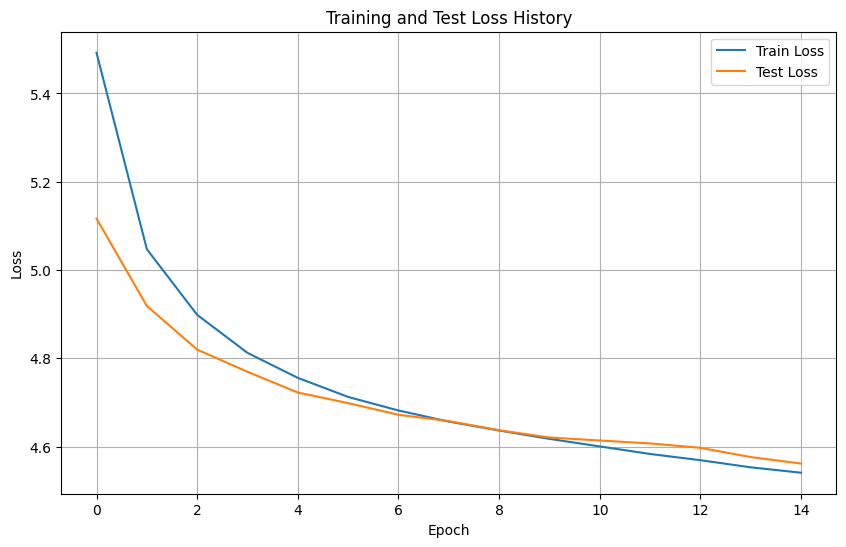

In [56]:
if len(train_loss_history) > 0 and len(val_loss_history) > 0:
    plt.figure(figsize=(10, 6))
    plt.plot(train_loss_history, label='Train Loss')
    plt.plot(val_loss_history, label='Test Loss')
    plt.title('Training and Test Loss History')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No loss history to plot.")

### Text Generation Function & Examples

In [64]:
def generate_text(
    model,
    prompt,
    seq_len=100,
    max_words=150,
    temperature=1.4,
    top_k=20
):
    model.eval()
    generated_words = prompt.lower().split()
    with torch.no_grad():
        for _ in range(max_words):
            # ----------------------------------
            # Encode current text
            # ----------------------------------
            encoded = [
                word2idx.get(word, word2idx["<UNK>"])
                for word in generated_words
            ]

            # Keep only last seq_len tokens
            encoded = encoded[-seq_len:]

            # Left padding if needed
            if len(encoded) < seq_len:
                encoded = (
                    [word2idx["<PAD>"]] * (seq_len - len(encoded))
                    + encoded
                )
            x = torch.tensor(
                encoded,
                dtype=torch.long
            ).unsqueeze(0).to(device)

            # ----------------------------------
            # Model Prediction
            # ----------------------------------
            logits = transformer_model(x)

            # Never generate PAD or UNK
            logits[:, word2idx["<PAD>"]] = -float("inf")
            logits[:, word2idx["<UNK>"]] = -float("inf")

            # Temperature Scaling
            logits = logits / temperature

            # ----------------------------------
            # Top-K Sampling
            # ----------------------------------
            top_values, top_indices = torch.topk(
                logits,
                k=top_k,
                dim=-1
            )

            probs = F.softmax(
                top_values,
                dim=-1
            )

            sampled_position = torch.multinomial(
                probs.squeeze(),
                num_samples=1
            )

            next_token = (
                top_indices.squeeze()[sampled_position]
                .item()
            )

            next_word = idx2word[next_token]
            generated_words.append(next_word)

    return " ".join(generated_words)

In [63]:
# Test 1:
lyrics_1 = generate_text(
    model=transformer_model,
    prompt="i hate",
    seq_len=50,
    max_words=140,
    temperature=1.4
)

print(lyrics_1)

# Test 2
lyrics_2 = generate_text(
    model=transformer_model,
    prompt="you better",
    seq_len=20,
    max_words=40,
    temperature=1.4
)

print(lyrics_2)

# Test 3
lyrics_3 = generate_text(
    model=transformer_model,
    prompt="love is",
    temperature=1.4,
)

print(lyrics_3)

i hate that nicki a rock a this yuh this a boy and nicki nicki minaj if my nicki boy yo they say yo it girl nicki minaj yo yo them bitches and she said that anything they know this is just in front of the deal if i dont be with the day we gon' go i'm a couple grand niggas that money you see what the world with nicki minaj yo nicki minaj they want me in your face you gotta say you know this shit go up in a bitch nigga you play the zone i know what are like a big ego i'mma tell me i'm a bad bitch yeah i get me a real big reputation yeah you better i'm just for a nigga i get it i don't need to me how much bitch and i'ma
you better off rock with you and i say i let you off yeah and if i can't go boy i'm on a star 'cause your body rock and you don't give it then you don't let the streets get it on
love is the them and the party all the i did let her girls at me for these they get y'all they don't have a girl im nicki a girl she don't want no women them boy nicki all you if nicki the sight o